<a href="https://colab.research.google.com/github/d1jeett/dap-2024/blob/main/les05/rep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №5. Визуализация данных

In [1]:
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

print(f"Python version: {sys.version}")
print(f"Numpy version: {np.version.version}")
print(f"Matplotlib version: {mpl.__version__}")

%matplotlib inline

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Numpy version: 2.0.2
Matplotlib version: 3.10.0


In [10]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # выберите файл titanic.csv

df = pd.read_csv('titanic.csv')
df.head()

Saving titanic.csv to titanic.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Задача **1**

Постройте два линейных графика функции $y=\frac{2}{x}+3$ на одной оси координат, первый для диапазона x=[-10;0], а второй для x=[0;7].

* Графики должны быть помещены на оси с пределами xlim(-10, 10) и ylim(-10, 10), иметь подписи к осям, легенду и заголовок.
* Первый график должен быть красного цвета и нарисован штрихпунктирной линией
* Второй график должен иметь цвет (1.0,0.2,0.3) и нарисован сплошной линией


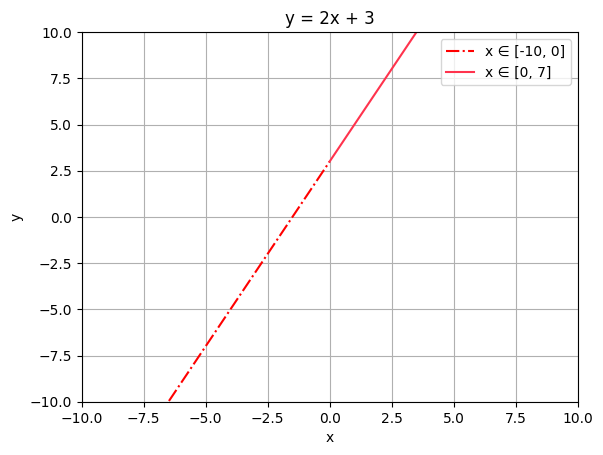

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x1 = np.linspace(-10, 0, 100)
x2 = np.linspace(0, 7, 100)

plt.plot(x1, 2*x1+3, 'r-.', label='x ∈ [-10, 0]')
plt.plot(x2, 2*x2+3, color=(1.0, 0.2, 0.3), label='x ∈ [0, 7]')

plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.xlabel('x')
plt.ylabel('y')
plt.title('y = 2x + 3')
plt.legend()
plt.grid(True)
plt.show()


Задача **2**

Постройте диаграмму рассеяния для набора данных titanic (файл ./data/titanic.csv).

* По оси X - возврат пассажира (Age)
* По оси Y - стоимость билета (Fare)
* Для выживших пассажиров используется маркер зеленый круг (Survived)
* Для не выживших пассажиров используется маркер красный крест (Survived)
* График должен подписи к осям и легенду и заголовок

Данные для которых не указан возврат или стоимость билета должны быть исключены

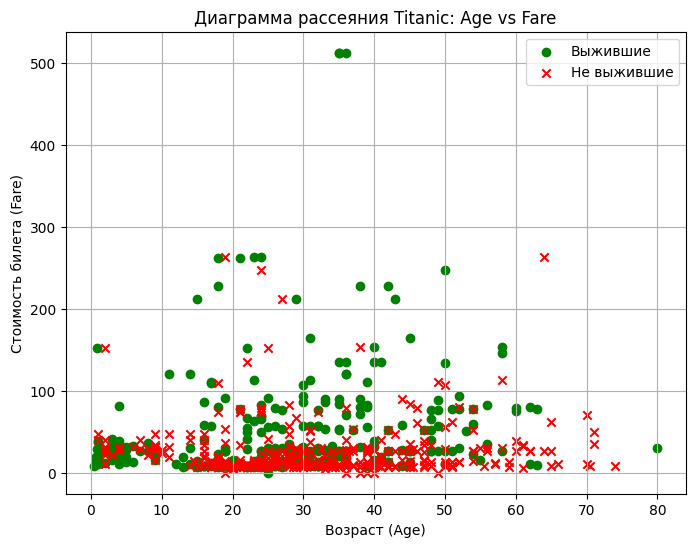

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv')

df_clean = df.dropna(subset=['Age', 'Fare'])

plt.figure(figsize=(8,6))

survived = df_clean[df_clean['Survived']==1]
plt.scatter(survived['Age'], survived['Fare'], color='green', marker='o', label='Выжившие')

not_survived = df_clean[df_clean['Survived']==0]
plt.scatter(not_survived['Age'], not_survived['Fare'], color='red', marker='x', label='Не выжившие')

plt.xlabel('Возраст (Age)')
plt.ylabel('Стоимость билета (Fare)')
plt.title('Диаграмма рассеяния Titanic: Age vs Fare')
plt.legend()
plt.grid(True)

plt.show()


Задача **3**

Для первоначального анализа данных часто используются диаграммы рассеяния для всех признаков из набора данных. Это позволяет визуально увидеть зависимости между признаками и выбросы.
Для набора данных [iris](https://ru.wikipedia.org/wiki/%D0%98%D1%80%D0%B8%D1%81%D1%8B_%D0%A4%D0%B8%D1%88%D0%B5%D1%80%D0%B0) постройте на одном холсте 16 диаграмм рассеяния показывающих зависимости между всеми признаками набора ('sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)')

* Холст должен содержать 16 графиков на отдельных осях (см. иллюстрацию к статье в Википедия)
* Цвет маркеров должен зависеть от вида ирисов (iris.target)
* Графики должны иметь подписи к осям, легенду и общий заголовок

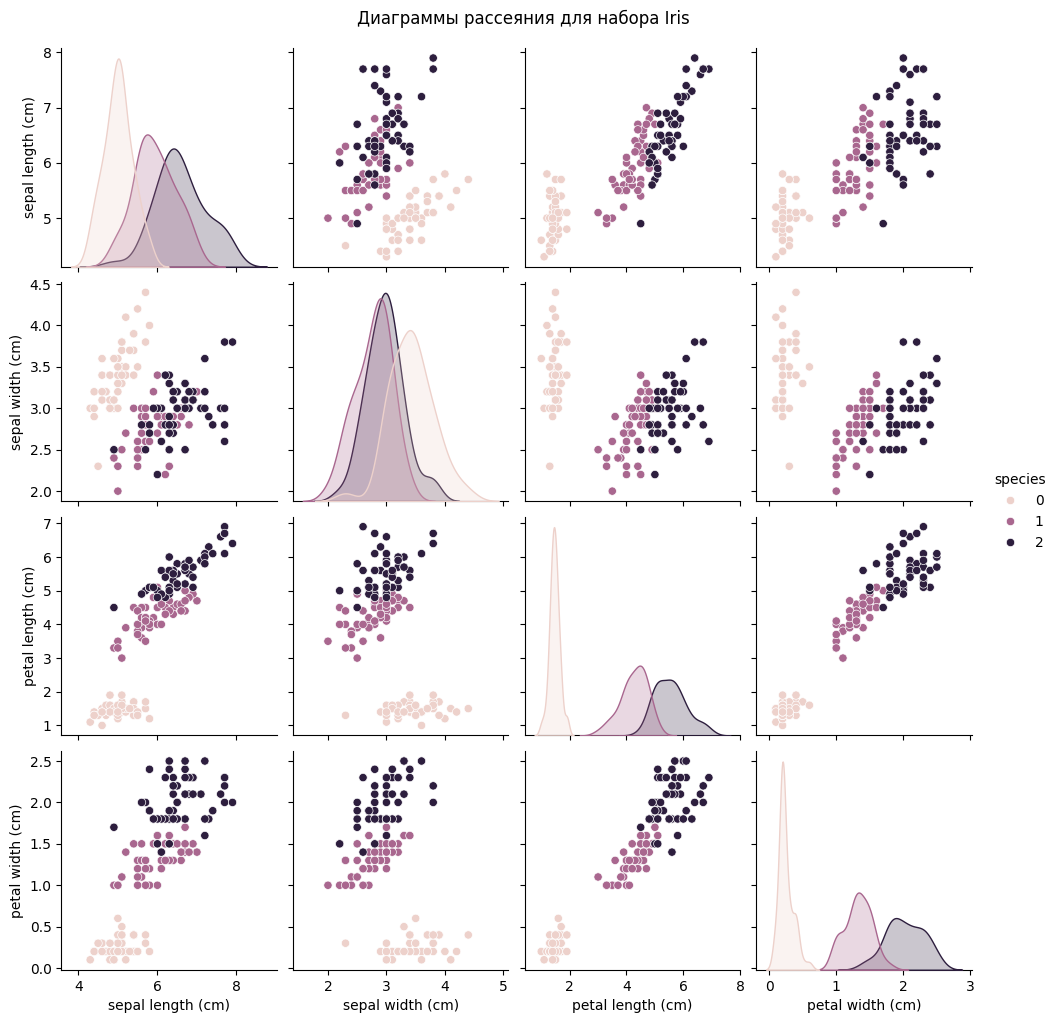

In [18]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import seaborn as sns
import pandas as pd

# Загрузка данных Iris
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target

# Создание парных диаграмм рассеяния
sns.pairplot(iris_df, hue='species')

# Добавление заголовка
plt.suptitle('Диаграммы рассеяния для набора Iris', y=1.02)

plt.show()

Задача **4**

Постройте на одном холсте и разный осях следующие распределения для набора данных titanic (./data/titanic.csv):

* Постройте гистограмму распределения пассажиров по возрасту (Age). Интервал 5 лет.
* Постройте гистограмму распределения пассажиров женского пола по стоимости билетов (Fare). Подберите удобный интервал
* График должен иметь подписи к осям, легенду и заголовок

Данные для которых не указан возраст или стоимость билета должны быть исключены

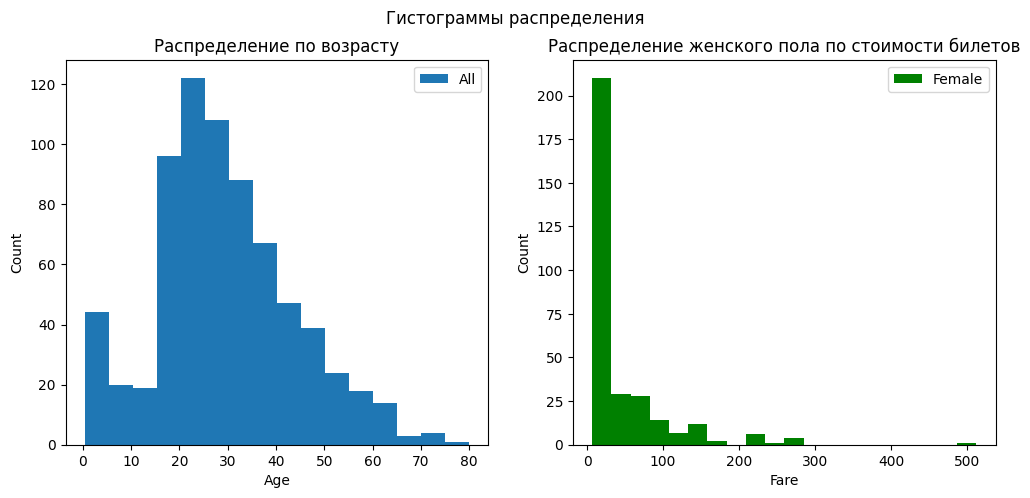

In [24]:
titanic_df = pd.read_csv("titanic.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Гистограммы распределения")
axes[0].hist(titanic_df['Age'], bins = 16, label='All')
axes[0].set_title("Распределение по возрасту")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
female = titanic_df[titanic_df['Sex'] == 'female']
axes[1].hist(female['Fare'], bins=20, color='green', label='Female')
axes[1].set_title("Распределение женского пола по стоимости билетов")
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Count")
axes[0].legend()
axes[1].legend()

Задача **5**

Для набора данных для набора данных titanic (./data/titanic.csv) постройте следующую столбчатую диаграмму:

* Диаграмма должна быть вертикальной
* По оси X - класс каюты пассажира (Pclass)
* По оси Y - средняя стоимость за проезд для данного класса (Fare)
* График должен иметь подписи к осям, легенду и заголовок

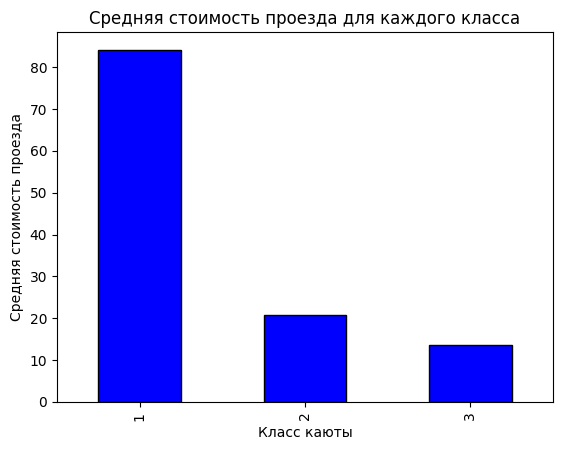

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('titanic.csv')

# Средняя стоимость проезда по классам
mean_fare = df.groupby('Pclass')['Fare'].mean()

# Построение столбчатой диаграммы
mean_fare.plot(kind='bar', color='blue', edgecolor='black')

# Подписи
plt.xlabel('Класс каюты')
plt.ylabel('Средняя стоимость проезда')
plt.title('Средняя стоимость проезда для каждого класса')

plt.show()

Задача **6**

Для набора данных для набора данных titanic (./data/titanic.csv) постройте следующую столбчатую диаграмму c накоплением:

* Диаграмма должна быть вертикальной
* По оси X - класс каюты пассажира (Pclass)
* По оси Y - количество пассажиров с разбивкой по полу (Sex)
* График должен иметь подписи к осям, легенду и заголовок

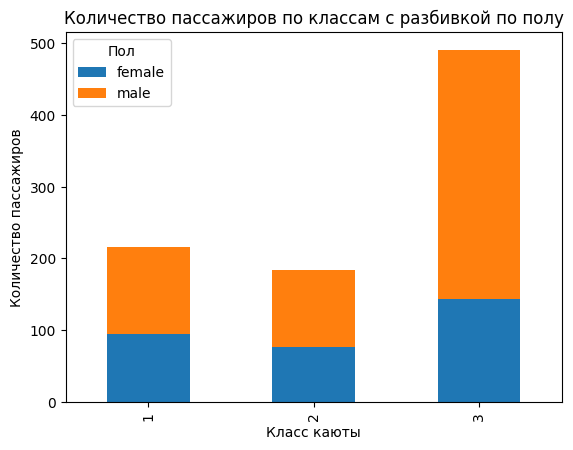

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('titanic.csv')

# Подсчет пассажиров по классам и полу
pclass_sex = df.groupby(['Pclass', 'Sex']).size().unstack()

# Построение диаграммы с накоплением
pclass_sex.plot(kind='bar', stacked=True)

# Подписи
plt.xlabel('Класс каюты')
plt.ylabel('Количество пассажиров')
plt.title('Количество пассажиров по классам с разбивкой по полу')

plt.legend(title='Пол')

plt.show()


Задача **7**

Для набора данных iris постройте круговую диаграмму

* Диаграмма должна иметь 3 сектора отражающих долю ирисов данного вида в наборе
* Сектор с максимальной долей долен быть выдвинут
* График должен иметь подписи к осям, легенду и заголовок

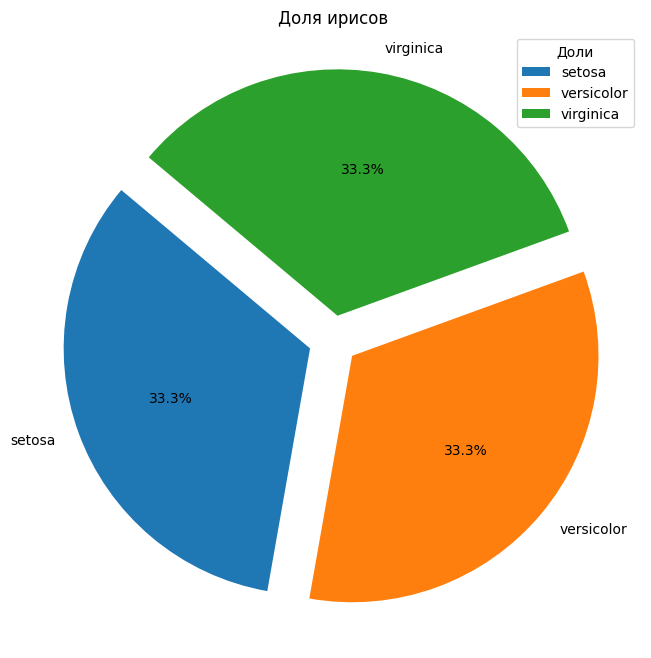

In [22]:
from sklearn.datasets import load_iris
iris = load_iris()
specn = iris.target_names
specow = np.bincount(iris.target)
labels = specn
sizes = specow
explode = [0.1 if size == max(sizes) else 0 for size in sizes]
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, explode=explode)
plt.title('Доля ирисов')
plt.legend(title="Доли")

Задача **8**

Использую библиотеку [Seaborn](https://seaborn.pydata.org/) постройте гистограмму для возраста пассажиров "Титаника"

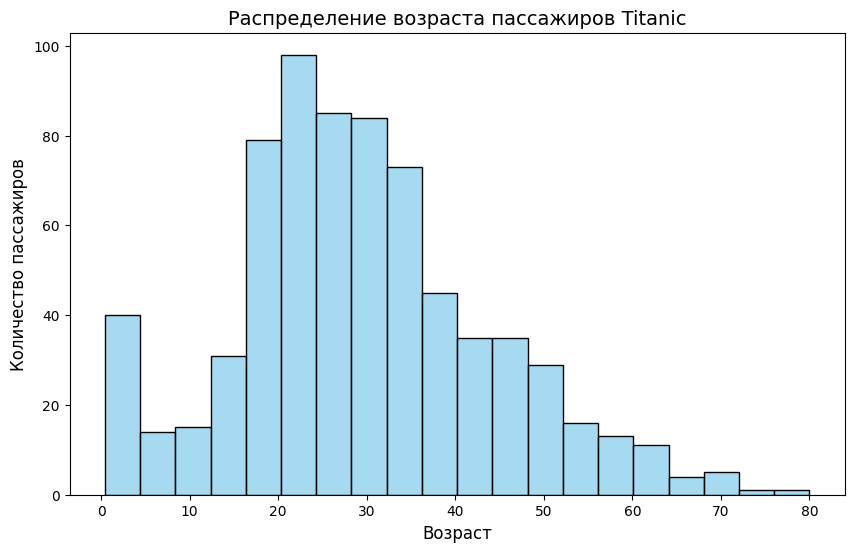

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

titanic = pd.read_csv("titanic.csv")
plt.figure(figsize=(10, 6))
sns.histplot(titanic['Age'].dropna(), kde=False, bins=20, color='skyblue', edgecolor='black')
plt.title('Распределение возраста пассажиров Titanic', fontsize=14)
plt.xlabel('Возраст', fontsize=12)
plt.ylabel('Количество пассажиров', fontsize=12)
plt.show()

## Вопросы


1. Для чего используется диаграмма рассеяния?
для визуализации связи между двумя числовыми переменными, поиска корреляций, кластеров и выбросов.
2. Что такое гистограмма, чем он отличается от столбчатой диаграммы?
показывает распределение одной числовой переменной (частоты в бинах). Столбчатая диаграмма — сравнивает категории (значения по категориям).
→ Гистограмма: для непрерывных данных, столбчатая: для категорий.
3. Как задать цвет линии в линейном графике Matplotlib?
```py
plt.plot(x, y, color='red')          # по имени
plt.plot(x, y, color='#FF0000')      # hex
plt.plot(x, y, color=(1.0, 0, 0))    # RGB
plt.plot(x, y, 'r-')                 # сокращение
```
4. Чем класс plt.Figure отличается от объекта  plt.Axes?
plt.Figure — весь холст (окно). plt.Axes — одна система координат (график) на холсте. → Одна Figure может содержать несколько Axes.
5. Matplotlib не позволяет управлять типом маркера scatter графика. Да или нет?
Нет, можно управлять: plt.scatter(x, y, marker='o')  # 'o', 's', '^', 'x', 'D', и т.д.
6. Matplotlib единственная библиотека для построения графиков в Python. Да или нет?
Нет, есть: Seaborn, Plotly, Bokeh, Altair, ggplot.
7. Matplotlib не позволяет сохранить график в виде файла, нужно делать скриншот?
Нет, сохранить можно: plt.savefig('график.png', dpi=300)
8. В наборе данных iris представлены 4 вида ирисов. Да или нет?
Нет, в iris 3 вида ирисов: setosa, versicolor, virginica.
9. Для всех пассажиров "Титаника" указан возраст. Да или нет?
Нет, в Titanic есть пропуски (NaN) в столбце Age.
10. Как на одном холсте может располагаться не более 16 диаграмм, это обусловлено тем что размер диаграммы нельзя изменить и более мелкие графики попросту не будут видны.
Нет, можно больше 16: fig, axes = plt.subplots(5, 5, figsize=(15, 10))  # 25 графиков